In [ ]:
import numpy as np
from datetime import date
from scipy import io as sio
import matplotlib.pyplot as plt
import h5py
from scipy import ndimage
import time
import argparse
import xarray as xr
from scipy.ndimage import label
import time
import os
import sys
import pandas as pd

## Description

This script shows how to apply 2D (time-depth) rescaling and clustering approach onto MHW profiles over mhw events' persistence centers.

Follow the sections:
1. Rescale MHW profiles on depth dimension
2. Rescale MHW profiles on time dimension.
3. 2D clustering

## Rescale MHW profiles on depth dimension

### Functions

In [22]:
import ast
def read_MultiValues_metric(data, metricname,type_to_transform='float'):
    df = data
    metric_values = df.loc[df[0] == f"{metricname}", 1].values 
    if type_to_transform=='float':
        values = np.array(metric_values[0].strip('[]').split()).astype('float')
    elif type_to_transform=='string':
        values = ast.literal_eval(metric_values[0])
    return values

In [ ]:
def read_latlon_index_from_csv1(df, metric1_name="LAT_unique",metric2_name="LON_unique"):
    lat_values = df.loc[df[0] == f"{metric1_name}", 1].values
    lat_values = lat_values[0]
    lat_data = ast.literal_eval(lat_values)
       
    lon_values = df.loc[df[0] == f"{metric2_name}", 1].values
    lon_values = lon_values[0]
    lon_data = ast.literal_eval(lon_values)
       
    return lat_data, lon_data

In [ ]:
def read_month_metric_from_csv(csvdata, metric_name="mhw_months"):
        values = df.loc[df[0] == f"{metric_name}", 1].values
        values = values[0].strip('[]')
        values = np.array(values)
        data = np.array(values.item().split(', '), dtype=int)
        return data
    

In [ ]:
import re
def read_time_metric_from_csv(csvdata, metric_name="mhw_times"):
    df = csvdata
    values = df.loc[df[0] == f"{metric_name}", 1].values
    values = values[0].strip('[]')
    matches = re.findall(r"array\('(.+?)'",values)
    data = [str(item) for item in matches]
    return data  
   

In [ ]:
import numpy as np

def find_nearest_MHWgrid_latlon_to_center(center_lat, center_lon, MHW_lat_list, MHW_lon_list,severity):
    # Select MHW valid latitude and longitude
    valid_MHWlat_list = []
    valid_MHWlon_list = []
    for i,(lat_i, lon_i) in enumerate(zip(MHW_lat_list,MHW_lon_list)):
        sev =severity.sel(lat = lat_i).sel(lon=lon_i)
        mask = sev>= 1
        if np.any(mask.values):
            valid_MHWlat_list.append(lat_i)
            valid_MHWlon_list.append(lon_i)            
    # Convert to radians
    lat_rad = np.radians(valid_MHWlat_list)
    lon_rad = np.radians(valid_MHWlon_list)
    lat0_rad = np.radians(center_lat)
    lon0_rad = np.radians(center_lon)
    
    # Haversine formula
    dlat = lat_rad - lat0_rad
    dlon = lon_rad - lon0_rad
    a = np.sin(dlat/2)**2 + np.cos(lat0_rad) * np.cos(lat_rad) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    earth_radius_km = 6371
    distances = earth_radius_km * c
    
    # Find index of the nearest point
    index = np.argmin(distances)
    nearest_lat = valid_MHWlat_list[index]
    nearest_lon = valid_MHWlon_list[index]
    
    mask1 = severity.sel(lat=nearest_lat).sel(lon=nearest_lon)>=1
    if ~np.any(mask1.values):
        print("the grid doesn't have MHW")
 
    #print(f"Nearest point: ({nearest_lat}, {nearest_lon}) at index {nearest_index}")
    return nearest_lat,nearest_lon


### Test with single mhw event

In [ ]:
ds2 = xr.open_mfdataset('/your_severityindex_filepath/GLORYS_intp5m_temp_mhw_severity_intensity.mixedLayer_thermocline_pycnocline_depth.*.1993.2020.nc')
upper1000severity = ds2.mhw_severity_index.sel(depth=slice(0,1000))

In [ ]:
import glob
mhw_ind=68
file = glob.glob(f"./No.{mhw_ind}.MHWmetrics*.xlsx")# key=extract_number
df =pd.read_csv(file[0],header=None)

#### step1: Find persistence center

In [23]:
persistent_center = read_MultiValues_metric(df,'PersistenceCenter','string')

In [24]:
persistent_center_lat = persistent_center[0]
persistent_center_lon = persistent_center[1]
print("Persistence center location (lat,lon,depth): ", persistent_center)

Persistence center location (lat,lon,depth):  [-7.622222222222222, 56.03333333333333, 137.55555555555554]


In [26]:
# read lat, lon of affected area
lat_unique,lon_unique = read_latlon_index_from_csv1(df)

In [28]:
mhw_months = read_month_metric_from_csv(df)

MHW life time:  9 month


In each time, we need to find the closest grid to the center which has valid rescaled severity profile (MHW)

In [31]:
all_center_grid_index = []
center_lat_list = []
center_lon_list = []

In [ ]:
import pandas as pd
time_series = pd.date_range(start="1993-01", end="2020-12", freq="MS")#.strftime('%Y-%m')
for month_order in range(len(mhw_months)):
    print("month", time_series[mhw_months[month_order]])
    center_lat, center_lon = find_nearest_MHWgrid_latlon_to_center(persistent_center_lat, persistent_center_lon, lat_unique[month_order], lon_unique[month_order], upper1000severity.isel(time=mhw_months[month_order]))   
    print( "nearest grid to center: (", center_lat,center_lon, ")")
    center_lat_list.append(center_lat)
    center_lon_list.append(center_lon)
    nearest_index = np.where((np.array(lat_unique[month_order]) == center_lat) & (np.array(lon_unique[month_order]) == center_lon))[0][0]
    all_center_grid_index.append(nearest_index)

In [100]:
# consider the grid with most occurrence as the persistence center grid 
df = pd.DataFrame({'lat': center_lat_list, 'lon': center_lon_list})
most_common_row = df.value_counts().idxmax()
persistcentergrid_lat = most_common_row[0]
persistcentergrid_lon = most_common_row[1]

#### step2: Extend MHW profiles by 2months (one month before, one month after)

In [101]:
# Extract all profiles on the center grid during MHWtrack time
mhwprofiles = upper1000severity.isel(time=slice(mhw_months[0],mhw_months[-1]+1)).sel(lat=persistcentergrid_lat,lon=persistcentergrid_lon)

In [34]:
# Extend profiles by 2 months
minind = mhw_months[0]
maxind = mhw_months[-1]

# Ensure boundaries are within the valid range of time_series
start_ind = max(minind - 1, 0)
end_ind = min(maxind + 1, len(time_series) - 1)

start_time = time_series[start_ind]
end_time = time_series[end_ind]
print(start_time,' to ', end_time)

1997-08-01 00:00:00  to  1998-06-01 00:00:00


#### step3: Apply depth rescaling to profiles during the extended time

In [350]:
def process_and_concatenate_profiles(myseverity, mymld,mythermocline):
    
 # Function to interpolate and reassign st_ocean coordinates
    def interpolate_and_assign_depths(myprofile, new_depth_start, new_depth_end, total_depths):
            new_depths = xr.DataArray(np.arange(new_depth_start, new_depth_end + 5, 5), dims=["depth"])
            scaled_profile = xr.DataArray(np.zeros([myprofile.shape[0],len(new_depths)]),coords={"time":myprofile.time,"depth": new_depths})
            for i,each_profile in enumerate(myprofile):
                #print(i)
                valid_coords = each_profile['depth'].where(~np.isnan(each_profile).compute(), drop=True) # find the depth index for non-nan severity profile
                if valid_coords.size == 0 or valid_coords .count() == 0:
                    scaled_profile[i,:] = np.nan
                else:
                    interpolated_levels = np.linspace(valid_coords.min().item(), valid_coords.max().item(), total_depths)
                    scaled_profile[i,:] = each_profile.interp(depth=interpolated_levels).values
                        
            return scaled_profile

    if (mymld.isnull().any().values) | (mythermocline.isnull().any().values):
        print("no available mixed layer depth or thermocline depth found")
        concatenated_profile = xr.DataArray(np.ones([len(mymld.time),25])*np.nan,coords=dict(time=mymld.time,depth=np.arange(0,1,0.04)))
    
    else:
        # Adjust thermocline if it is above the MLD or within 10m of it (this will give at least 2 depth levels between mixed layer and thermocline for interpolation)
        adjusted_thermocline = xr.where((mythermocline<=  mymld) | (mythermocline <=  mymld + 10), mymld+ 10, mythermocline)
        #Ajust thermocline if it beyond 990m, then assign it 990m and assign thermocline 990m
        adjusted_thermocline = xr.where(adjusted_thermocline>990, 990, adjusted_thermocline)
        
        # Update the depth segments for 5m increments
        depths_mld, depths_mld_tcline, depths_bottom = 8, 8, 9
        
        # Processing each segment
        depths = myseverity.depth.values
        # mixed layer 
        mask = xr.DataArray(depths < mymld.values[:, np.newaxis], coords=myseverity.coords)
        prof_mld = myseverity.where(mask,drop=True)
        mld_temp_scaled = interpolate_and_assign_depths(prof_mld, 5, depths_mld * 5, depths_mld)
        
        
         #thermocline layer
        mask = xr.DataArray((depths > mymld.values[:, np.newaxis] ) & (depths< adjusted_thermocline.values[:, np.newaxis]), coords=myseverity.coords)
        prof_mld_tcline = myseverity.where(mask, drop=True)
        mld_tcline_temp_scaled = interpolate_and_assign_depths(prof_mld_tcline, depths_mld * 5 + 5, (depths_mld + depths_mld_tcline) * 5, depths_mld_tcline)
        
        # bottom layer
        mask = xr.DataArray(depths > adjusted_thermocline.values[:, np.newaxis],coords=myseverity.coords)
        prof_bottom = myseverity.where(mask, drop=True)
        bottom_temp_scaled = interpolate_and_assign_depths(prof_bottom, (depths_mld + depths_mld_tcline) * 5 + 5, 125, depths_bottom)
    
        # Concatenating the DataArrays
        concatenated_profile = xr.concat([mld_temp_scaled, mld_tcline_temp_scaled, bottom_temp_scaled], dim='depth').interpolate_na(dim='depth', method='linear')

    return concatenated_profile

In [269]:
# Extract all related MHW profiles on persistence center
mhw_profiles = upper1000severity.sel(time=slice(start_time,end_time)).sel(lat=persistcentergrid_lat,lon=persistcentergrid_lon)
mhw_mld = ds2.sel(time=slice(start_time,end_time)).sel(lat=persistcentergrid_lat,lon=persistcentergrid_lon).mixed_layer_depth
mhw_tcd = ds2.sel(time=slice(start_time,end_time)).sel(lat=persistcentergrid_lat,lon=persistcentergrid_lon).thermocline_base_depth

In [270]:
# Scale profiles on depth dimensions
scaled_mhwprof = process_and_concatenate_profiles(mhw_profiles,mhw_mld,mhw_tcd)
new_depth = np.arange(scaled_mhwprof['depth'].size)/25  # replace depth with unit length
scaled_mhwprof = scaled_mhwprof.assign_coords(depth=new_depth)

### Loop over event 

In [65]:
all_persistent_center_rescaled_seve = xr.DataArray(np.ones([536, len(time_series),25])*np.nan,coords=dict(event = range(536), time=time_series, depth = range(5,130,5)))
all_persistent_center_MLbase = xr.DataArray(np.zeros([536, len(time_series)]),coords=dict(event = range(536), time=time_series))
all_persistent_center_TCbase = xr.DataArray(np.zeros([536, len(time_series)]),coords=dict(event = range(536), time=time_series))

In [66]:
all_persistent_center_lat = xr.DataArray(np.zeros(536),coords=dict(event = range(536)))
all_persistent_center_lon = xr.DataArray(np.zeros(536),coords=dict(event = range(536)))

MHW # 424
Persistence center location (lat,lon,depth):  [-54.32747252747253, -57.371428571428574, 340.53846153846155]
MHW life time:  5 month
month 2017-04-01 00:00:00
nearest grid to center: ( -53.5 -57.5 )
final persiscenter grid:  -53.5 -57.5
Extended period: 2017-03-01 00:00:00  to  2017-09-01 00:00:00


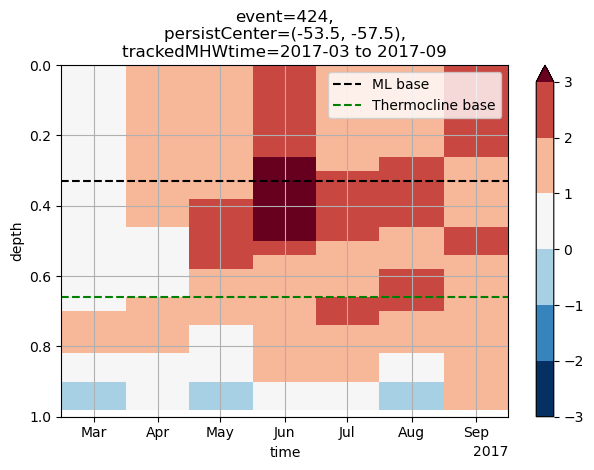

In [159]:
# all events

import glob

for mhw_ind in range(424,425):#len(tracks_sorted)
    print("MHW #",mhw_ind)
    file = glob.glob(f"./No.{mhw_ind}.MHWmetrics*.xlsx")# key=extract_number
    df =pd.read_csv(file[0],header=None)
    # load persistence center
    persistent_center = read_MultiValues_metric(df,'PersistenceCenter','string')
    persistent_center_lat = persistent_center[0]
    persistent_center_lon = persistent_center[1]
    print("Persistence center location (lat,lon,depth): ", persistent_center)
    
    # read lat, lon of affected area
    lat_unique,lon_unique = read_latlon_index_from_csv1(df)
    mhw_months = read_month_metric_from_csv(df)
    print("MHW life time: ",len(mhw_months), "month")
    # read time
    times = read_time_metric_from_csv(df)
    
    # find the nearest grid to persistence center
    all_center_grid_index = []
    center_lat_list = []
    center_lon_list = []
    for month_order in range(len(mhw_months[0:1])):
        print("month", time_series[mhw_months[month_order]])
        center_lat, center_lon = find_nearest_MHWgrid_latlon_to_center(persistent_center_lat, persistent_center_lon, lat_unique[month_order], lon_unique[month_order], upper1000severity.isel(time=mhw_months[month_order]))   
        print( "nearest grid to center: (", center_lat,center_lon, ")")
        center_lat_list.append(center_lat)
        center_lon_list.append(center_lon)
        nearest_index = np.where((np.array(lat_unique[month_order]) == center_lat) & (np.array(lon_unique[month_order]) == center_lon))[0][0]
        all_center_grid_index.append(nearest_index)
       
    # consider the grid with most occurrence as the persistence center grid (here need revise codes!)
    df = pd.DataFrame({'lat': center_lat_list, 'lon': center_lon_list})
    most_common_row = df.value_counts().idxmax()
    persistcentergrid_lat = most_common_row[0]
    persistcentergrid_lon = most_common_row[1]
    print("final persiscenter grid: ", persistcentergrid_lat,  persistcentergrid_lon)

    # Extend profiles by 2 months
    minind = mhw_months[0]
    maxind = mhw_months[-1]
    
    # Ensure boundaries are within the valid range of time_series (one month before, one month after)
    start_ind = max(minind - 1, 0)
    end_ind = min(maxind + 1, len(time_series) - 1)
    
    start_time = time_series[start_ind]
    end_time = time_series[end_ind]
    print("Extended period:", start_time,' to ', end_time)
    
    # Extract all profiles on the center grid during exyended time
    mhw_profiles = upper1000severity.sel(time=slice(start_time,end_time)).sel(lat=persistcentergrid_lat,lon=persistcentergrid_lon)
    mhw_mld = ds2.sel(time=slice(start_time,end_time)).sel(lat=persistcentergrid_lat,lon=persistcentergrid_lon).mixed_layer_depth
    mhw_tcd = ds2.sel(time=slice(start_time,end_time)).sel(lat=persistcentergrid_lat,lon=persistcentergrid_lon).thermocline_base_depth

    # Scale profiles on depth dimensions
    scaled_mhwprof = process_and_concatenate_profiles(mhw_profiles,mhw_mld,mhw_tcd)
    new_depth = np.arange(scaled_mhwprof['depth'].size)/25  # replace depth with unit length
    scaled_mhwprof = scaled_mhwprof.assign_coords(depth=new_depth)

    # Visualize the rescaled profiles during MHW periods
    plt.figure()
    scaled_mhwprof.plot.pcolormesh(y='depth',cmap='RdBu_r',levels=np.arange(-3,4,1)) 
    plt.ylim(0,1)
    plt.xticks(scaled_mhwprof.time.values)
    plt.grid(True)
    plt.axhline(.33, color='black', linestyle='--',label='ML base')
    plt.axhline(.66, color='green', linestyle='--',label='Thermocline base')
    plt.title(f"event={mhw_ind},\npersistCenter={persistcentergrid_lat,persistcentergrid_lon},\ntrackedMHWtime={pd.to_datetime(mhw_profiles.time[0].values).strftime('%Y-%m')} to {pd.to_datetime(mhw_profiles.time[-1].values).strftime('%Y-%m')}")
    plt.legend()
    plt.gca().invert_yaxis()
    plt.tight_layout()

    starttime_index = np.where(time_series==start_time)[0][0]
    endtime_index = np.where(time_series==end_time)[0][0]
    all_persistent_center_rescaled_seve[mhw_ind,starttime_index:endtime_index+1,:]= scaled_mhwprof.values
    all_persistent_center_MLbase[mhw_ind,starttime_index:endtime_index+1] =  mhw_mld
    all_persistent_center_TCbase[mhw_ind,starttime_index:endtime_index+1] = mhw_tcd
    all_persistent_center_lat[mhw_ind] = persistcentergrid_lat
    all_persistent_center_lon[mhw_ind] = persistcentergrid_lon
    
new_depth = np.arange(all_persistent_center_rescaled_seve['depth'].size)/25  # Assuming depth levels match the depth dimension size
all_persistent_center_rescaled_seve = all_persistent_center_rescaled_seve.assign_coords(depth=new_depth)

In [ ]:
all_perscenter_data = all_persistent_center_rescaled_seve.to_dataset(name="center_rescaled_severity")
all_perscenter_data["center_lat"] = all_persistent_center_lat
all_perscenter_data["center_lon"] = all_persistent_center_lon

all_perscenter_data["center_MLbase"] = all_persistent_center_MLbase
all_perscenter_data["center_TCbase"] = all_persistent_center_TCbase

all_perscenter_data.attrs = dict(data="This is rescalced severity index profile on the persistence center during each single MHW event. The persistence center is the mean locations of areas where MHW persist longest throughout liftime. The profile is extended by pervious and post 2 months to include more evolution info.")

In [ ]:
#all_perscenter_data.to_netcdf("/your_output_fileput/MHW_perscenter_depthrescaled_profiles.nc")

## Rescale MHW profiles on time dimension

In [167]:
all_perscenter_data = all_perscenter_data.rename({"depth": "unit_depth"})

In [168]:
new_unit_time = np.linspace(0, 1, 13)
eventnumber = 536#len(tracks_sorted)
all_rescaled_severity_2Ddata = xr.DataArray(np.zeros([eventnumber,len(new_unit_time),25]),coords=dict(event=range(eventnumber),unit_time=new_unit_time,unit_depth=np.linspace(0,1,25)))
all_mhwmonths = xr.DataArray(np.zeros(eventnumber), coords=dict(event=range(eventnumber)))
for mhw_ind in range(eventnumber):
    print("MHW #",mhw_ind)
    eventdata = all_perscenter_data.isel(event=mhw_ind)
    da = eventdata.center_rescaled_severity.dropna("time")
    rescaledSev = da
    all_mhwmonths[mhw_ind] = len(da.time)
    # Normalize time dimension
    if len(da.time)>0:
        # Step 1: Convert time to normalized unit time [0, 1]
        t_min = rescaledSev.time.values[0]
        t_max = rescaledSev.time.values[-1]
        t_unit = ((rescaledSev.time - t_min) / (t_max - t_min)).values  # normalized time in [0, 1]
        
        # Step 2: Assign new normalized time as coordinate
        rescaledSev.coords['unit_time'] = ('time', t_unit)
        rescaledSev = rescaledSev.swap_dims({'time': 'unit_time'})  # use 'unit_time' as the interpolation dimension
        
        # Step 3: Interpolate to 5 evenly spaced unit time steps
        rescaledSev_interp = rescaledSev.interp(unit_time=new_unit_time)
        #rescaledSev_interp.plot(y='depth')
        all_rescaled_severity_2Ddata[mhw_ind] = rescaledSev_interp.values
    else:
        all_rescaled_severity_2Ddata[mhw_ind] = np.nan

MHW # 0
MHW # 1
MHW # 2
MHW # 3
MHW # 4
MHW # 5
MHW # 6
MHW # 7
MHW # 8
MHW # 9
MHW # 10
MHW # 11
MHW # 12
MHW # 13
MHW # 14
MHW # 15
MHW # 16
MHW # 17
MHW # 18
MHW # 19
MHW # 20
MHW # 21
MHW # 22
MHW # 23
MHW # 24
MHW # 25
MHW # 26
MHW # 27
MHW # 28
MHW # 29
MHW # 30
MHW # 31
MHW # 32
MHW # 33
MHW # 34
MHW # 35
MHW # 36
MHW # 37
MHW # 38
MHW # 39
MHW # 40
MHW # 41
MHW # 42
MHW # 43
MHW # 44
MHW # 45
MHW # 46
MHW # 47
MHW # 48
MHW # 49
MHW # 50
MHW # 51
MHW # 52
MHW # 53
MHW # 54
MHW # 55
MHW # 56
MHW # 57
MHW # 58
MHW # 59
MHW # 60
MHW # 61
MHW # 62
MHW # 63
MHW # 64
MHW # 65
MHW # 66
MHW # 67
MHW # 68
MHW # 69
MHW # 70
MHW # 71
MHW # 72
MHW # 73
MHW # 74
MHW # 75
MHW # 76
MHW # 77
MHW # 78
MHW # 79
MHW # 80
MHW # 81
MHW # 82
MHW # 83
MHW # 84
MHW # 85
MHW # 86
MHW # 87
MHW # 88
MHW # 89
MHW # 90
MHW # 91
MHW # 92
MHW # 93
MHW # 94
MHW # 95
MHW # 96
MHW # 97
MHW # 98
MHW # 99
MHW # 100
MHW # 101
MHW # 102
MHW # 103
MHW # 104
MHW # 105
MHW # 106
MHW # 107
MHW # 108
MHW # 109
MHW # 110


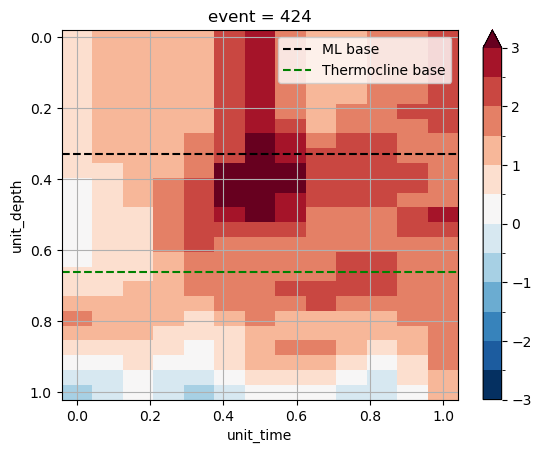

In [169]:
data =all_rescaled_severity_2Ddata.sel(event=424)
data.plot(y='unit_depth',levels=np.arange(-3,3.5,0.5))
plt.gca().invert_yaxis()
plt.grid(True)
plt.axhline(.33, color='black', linestyle='--',label='ML base')
plt.axhline(.66, color='green', linestyle='--',label='Thermocline base')
plt.legend()

In [170]:
#all_rescaled_severity_2Ddata.to_netcdf("/your_output_filepath/MHW_perscenter_2Drescaled_profiles.nc")

## 2D (time-depth) clustering

In [3]:
all_rescaled_severity_2Ddata

<xarray.DataArray (event: 536, unit_time: 13, unit_depth: 25)> Size: 1MB
[174200 values with dtype=float64]
Coordinates:
  * event       (event) int64 4kB 0 1 2 3 4 5 6 ... 529 530 531 532 533 534 535
  * unit_time   (unit_time) float64 104B 0.0 0.08333 0.1667 ... 0.9167 1.0
  * unit_depth  (unit_depth) float64 200B 0.0 0.04167 0.08333 ... 0.9583 1.0

In [4]:
(n_events,  n_time, n_depth) = all_rescaled_severity_2Ddata.shape


In [5]:
# Flatten each location's depth-time matrix into a 1D vector
data_for_clustering = all_rescaled_severity_2Ddata.values.reshape(n_events, -1)  # shape: (n_locations, n_depth * n_time)


In [27]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from scipy.cluster.hierarchy import dendrogram
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import linkage

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
#data_scaled = scaler.fit_transform(data_for_clustering)
# Impute missing values (but I don't have missing values in my profiles)
#print(np.isnan(data_scaled).any())
imputer = SimpleImputer(missing_values=np.nan, strategy='median')
data_imputed = imputer.fit_transform(data_for_clustering)
data_scaled = scaler.fit_transform(data_imputed)  # Assuming data_imputed is your preprocessed data
print(np.isnan(data_scaled).any())

In [ ]:
# Without specifying the number of clusters upfront, to see the dendrogram
clustering = AgglomerativeClustering(distance_threshold=0, n_clusters=None, linkage='ward')
model = clustering.fit(data_scaled)

In [ ]:
from sklearn.cluster import AgglomerativeClustering

n_clusters = 7  # for example
model = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
labels = model.fit_predict(data_scaled)  # shape: (n_locations,)
labels = labels+1

In [ ]:
mean_rescaled_profiles_2D = xr.DataArray(np.zeros([n_clusters,13,25]),
                                         coords=dict(cluster=range(1,8), unit_time=all_rescaled_severity_2Ddata.unit_time.values, unit_depth = all_rescaled_severity_2Ddata.unit_depth.values))

In [ ]:
for cluster_id in range(1,8):
    mean_rescaled_profiles_2D[cluster_id-1] = all_rescaled_severity_2Ddata[labels == cluster_id].mean(axis=0)
    

In [ ]:
for cluster_id in range(1,8):
    singlecluster_MHWs_2Ddata = all_rescaled_severity_2Ddata[labels == cluster_id]